In [83]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage

In [84]:
load_dotenv()

True

In [85]:
class AgentState(MessagesState):
    summary: str

In [86]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite"
)

In [87]:
def chat_node(state: AgentState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation Summary:\n {state['summary']}"
        })
    
    messages.extend(state["messages"])

    response = llm.invoke(messages)
    return {
        "messages": [response]
    }

In [88]:
def summarize_node(state: AgentState):
    existing_summary = state.get("summary", "")

    if existing_summary:
        prompt = f"""Extend the summary using this existing summmary: {existing_summary}
        Summarize the conversation using the conversation above.
        """
    else:
        prompt = f"""Summarize the conversation using the conversation above."""

    messages_for_summary = state['messages'] + [
        HumanMessage(content=prompt)
    ]

    summary = llm.invoke(messages_for_summary)

    messages_to_delete = state["messages"][:-2]

    return {
        "summary": summary.content[0]['text'],
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [89]:
def should_summarize(state: AgentState):
    return len(state["messages"]) > 6

In [90]:
builder = StateGraph(AgentState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: END,
    }
)

builder.add_edge("summarize", END)

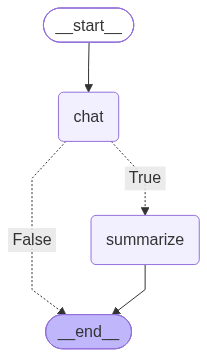

In [91]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [92]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [93]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [94]:
run_turn('Quantum Physics')
show_state()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': '**Quantum Physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the everyday world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe operates under a bizarre, counterintuitive set of rules.\n\nHere is a breakdown of the core concepts, principles, and real-world impacts of quantum physics.\n\n---\n\n### 1. The Core Principles\n\n*   **Quantization:** In the quantum world, certain properties (like energy, angular momentum, and light) are not continuous. Instead, they come in discrete packets called **quanta**. Ima

In [95]:
run_turn('How is Albert Einstien related?')
show_state()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': '**Quantum Physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the everyday world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe operates under a bizarre, counterintuitive set of rules.\n\nHere is a breakdown of the core concepts, principles, and real-world impacts of quantum physics.\n\n---\n\n### 1. The Core Principles\n\n*   **Quantization:** In the quantum world, certain properties (like energy, angular momentum, and light) are not continuous. Instead, they come in discrete packets called **quanta**. Ima

In [96]:
run_turn('What are some of Einstien"s fampus work')
show_state()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': '**Quantum Physics** (also known as quantum mechanics or quantum theory) is the branch of physics that studies the behavior of matter and energy at the smallest scales—typically at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (Newtonian physics) explains how the everyday world works—like how a baseball flies or how planets orbit the sun—it completely breaks down at the microscopic level. In the quantum realm, the universe operates under a bizarre, counterintuitive set of rules.\n\nHere is a breakdown of the core concepts, principles, and real-world impacts of quantum physics.\n\n---\n\n### 1. The Core Principles\n\n*   **Quantization:** In the quantum world, certain properties (like energy, angular momentum, and light) are not continuous. Instead, they come in discrete packets called **quanta**. Ima

In [97]:
run_turn('Explain special theory of relativity')
show_state()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



--- STATE ---
summary: Here is a summary of our conversation:

*   **Quantum Physics:** We began by defining quantum physics as the study of matter and energy at the microscopic (atomic and subatomic) scale. We covered its core principles—like quantization, wave-particle duality, superposition, entanglement, and the Heisenberg Uncertainty Principle—as well as its massive real-world impact on technologies like semiconductors, lasers, MRIs, and quantum computing.
*   **Albert Einstein's Relationship with Quantum Physics:** We discussed how Einstein was both a pioneer (winning his Nobel Prize for explaining the photoelectric effect, which helped launch quantum theory) and a famous skeptic. He famously rejected the probabilistic nature of the quantum world ("God does not play dice") and dismissed entanglement as "spooky action at a distance"—though experiments ultimately proved him wrong on those points.
*   **Einstein's Famous Works:** We reviewed his breakthroughs from his 1905 "Miracle

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
